# VEV — Counterparty (Mark) Behavior

R4 trade files include `buyer` / `seller`. The VEV strike chain (4000–6500)
has four active Marks: **01**, **14**, **22**, **38**. Goal: figure out
who is doing what, where the PnL transfer happens, and whether any of the
flow is followable.

This notebook is the exploratory companion to `vev_counterparty/REPORT.md`
and `build_vev_counterparty_report.py`. Same compute, but with insights
written inline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA = Path('../Data')

VEV_ORDER = [
    'VEV_4000','VEV_4500','VEV_5000','VEV_5100','VEV_5200',
    'VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500',
]
HORIZONS = [1_000, 5_000, 10_000, 50_000, 100_000]

prices = pd.concat([
    pd.read_csv(DATA / f'prices_round_4_day_{d}.csv', sep=';').assign(day=d)
    for d in [1, 2, 3]
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(DATA / f'trades_round_4_day_{d}.csv', sep=';').assign(day=d)
    for d in [1, 2, 3]
], ignore_index=True)

prices = prices[prices['product'].isin(VEV_ORDER)].copy()
trades = trades[trades['symbol'].isin(VEV_ORDER)].copy()
print(f'prices rows: {len(prices)}, trade rows: {len(trades)}')
print(f'days: {sorted(trades.day.unique())}, products: {sorted(trades.symbol.unique())}')

prices rows: 300000, trade rows: 1878
days: [np.int64(1), np.int64(2), np.int64(3)], products: ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


## 1 — Build per-Mark fill table

In [2]:
# Each public trade has a buyer Mark and a seller Mark — expand into 2 rows
# (one per side) so we can group by Mark.

def classify_role(price, bid, ask, mid, side):
    if not np.isnan(bid) and not np.isnan(ask):
        if side > 0:
            if price >= ask: return 'taker'
            if price <= bid: return 'passive'
        else:
            if price <= bid: return 'taker'
            if price >= ask: return 'passive'
    if not np.isnan(mid):
        prem = side * (price - mid)
        if prem > 0: return 'taker_like'
        if prem < 0: return 'passive_like'
    return 'unknown'


qcols = ['day','timestamp','product','bid_price_1','ask_price_1','mid_price']
quotes = prices[qcols].rename(columns={'product':'symbol'})
enriched = trades.merge(quotes, on=['day','timestamp','symbol'], how='left')

rows = []
for r in enriched.itertuples(index=False):
    for mark, side in [(r.buyer, 1), (r.seller, -1)]:
        bid = r.bid_price_1; ask = r.ask_price_1; mid = r.mid_price
        price = float(r.price); qty = float(r.quantity)
        role = classify_role(price, bid, ask, mid, side)
        prem = side * (price - mid) if not np.isnan(mid) else np.nan
        rows.append({
            'day': int(r.day), 'timestamp': int(r.timestamp),
            'global_ts': (int(r.day) - 1) * 1_000_000 + int(r.timestamp),
            'product': r.symbol, 'mark': mark, 'side': side,
            'price': price, 'quantity': qty, 'signed_qty': side * qty,
            'cash_change': -side * price * qty,
            'mid_price': mid, 'entry_premium': prem,
            'aggression': role, 'buyer': r.buyer, 'seller': r.seller,
        })
fills = pd.DataFrame(rows)

# Final-mid PnL: mark each fill to the day's last mid for that product.
final_mid = (
    prices.sort_values('timestamp').groupby(['day','product']).tail(1)
    [['day','product','mid_price']].rename(columns={'mid_price':'final_mid'})
)
fills = fills.merge(final_mid, on=['day','product'], how='left')
fills['final_pnl'] = fills['side'] * (fills['final_mid'] - fills['price']) * fills['quantity']

# Forward-mid edges at several horizons (per fill, per unit).
for h in HORIZONS:
    fut = prices[['day','timestamp','product','mid_price']].copy()
    fut['timestamp'] = fut['timestamp'] - h
    fut = fut.rename(columns={'mid_price': f'mid_t{h}'})
    fills = fills.merge(fut, on=['day','timestamp','product'], how='left')
    fills[f'hold_unit_{h}'] = fills['side'] * (fills[f'mid_t{h}'] - fills['price'])

print(f'fills rows: {len(fills)}, marks: {sorted(fills.mark.unique())}')
fills.head()

fills rows: 3756, marks: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38']


,day,timestamp,global_ts,product,mark,side,price,quantity,signed_qty,cash_change,...,mid_t1000,hold_unit_1000,mid_t5000,hold_unit_5000,mid_t10000,hold_unit_10000,mid_t50000,hold_unit_50000,mid_t100000,hold_unit_100000
0,1,4500,4500,VEV_5400,Mark 01,1,18.0,2.0,2.0,-36.0,...,18.5,0.5,17.0,-1.0,15.0,-3.0,16.0,-2.0,17.0,-1.0
1,1,4500,4500,VEV_5400,Mark 22,-1,18.0,2.0,-2.0,36.0,...,18.5,-0.5,17.0,1.0,15.0,3.0,16.0,2.0,17.0,1.0
2,1,4500,4500,VEV_5500,Mark 01,1,8.0,2.0,2.0,-16.0,...,8.5,0.5,7.5,-0.5,6.5,-1.5,7.5,-0.5,7.5,-0.5
3,1,4500,4500,VEV_5500,Mark 22,-1,8.0,2.0,-2.0,16.0,...,8.5,-0.5,7.5,0.5,6.5,1.5,7.5,0.5,7.5,0.5
4,1,4500,4500,VEV_6000,Mark 01,1,0.0,2.0,2.0,-0.0,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


**Read.** ~3,750 underlying VEV trades blow up to ~7,500 fill-rows once we
attribute each leg to a Mark. Four counterparties active across all
strikes.

## 2 — Mark-level summary

In [3]:
def agg_mark(df):
    g = df.groupby('mark', observed=True)
    out = g.agg(
        trades=('quantity','size'),
        gross_qty=('quantity','sum'),
        net_qty=('signed_qty','sum'),
        final_pnl=('final_pnl','sum'),
        avg_entry_premium=('entry_premium','mean'),
    )
    out['taker_pct'] = (
        df.assign(is_taker=df.aggression.isin(['taker','taker_like']))
          .groupby('mark', observed=True)
          .apply(lambda x: (x.is_taker * x.quantity).sum() / x.quantity.sum())
    )
    return out.sort_values('gross_qty', ascending=False).round(3)

mark_summary = agg_mark(fills)
print(mark_summary.to_string())

         trades  gross_qty  net_qty  final_pnl  avg_entry_premium  taker_pct
mark                                                                        
Mark 22    1439     4972.0  -4936.0    -7388.5              0.550      0.991
Mark 01    1339     4636.0   4636.0     5734.0             -0.569      0.000
Mark 14     522     1172.0    348.0    10884.5             -8.890      0.000
Mark 38     456      904.0    -48.0    -9230.0             10.113      1.000


/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_15461/2445594679.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.assign(is_taker=df.aggression.isin(['taker','taker_like']))


**Read — the four roles, in one table.**

- **Mark 22** (1439 trades, gross 4972, **−$7.4K**): runs almost entirely
  *taker* (99%) and is a structural net seller (net_qty ≈ −4936). He pays
  the spread on the way in.
- **Mark 01** (1339 trades, gross 4636, **+$5.7K**): mirror image —
  100% *passive*, structural net buyer. Captures spread from Mark 22.
- **Mark 14** (522 trades, gross 1172, **+$10.9K**): also 100% *passive*,
  smaller volume but the biggest PnL line. Concentrated in the deep-ITM
  strike (4000).
- **Mark 38** (456 trades, gross 904, **−$9.2K**): 100% *taker* against
  Mark 14. Symmetric counterparty to Mark 14 just like 01↔22.

So VEV is *two parallel duels*: Mark 01 vs Mark 22 on OTM strikes, and
Mark 14 vs Mark 38 on deep ITM. In each duel one side is the passive
quoter (banking spread) and the other is the cross-the-spread aggressor.

## 3 — Mark × Product summary table

In [4]:
def agg_mark_product(df):
    g = df.groupby(['mark','product'], observed=True)
    out = g.agg(
        trades=('quantity','size'),
        gross_qty=('quantity','sum'),
        buy_qty=('quantity', lambda x: df.loc[x.index].query('side > 0')['quantity'].sum()),
        sell_qty=('quantity', lambda x: df.loc[x.index].query('side < 0')['quantity'].sum()),
        net_qty=('signed_qty','sum'),
        cash=('cash_change','sum'),
        final_pnl=('final_pnl','sum'),
        avg_entry_premium=('entry_premium','mean'),
    ).reset_index()
    taker = (
        df.assign(is_taker=df.aggression.isin(['taker','taker_like']))
          .groupby(['mark','product'], observed=True)
          .apply(lambda x: pd.Series({
              'taker_qty': (x.is_taker * x.quantity).sum(),
              'passive_qty': ((~x.is_taker) * x.quantity).sum(),
          }))
          .reset_index()
    )
    out = out.merge(taker, on=['mark','product'], how='left')
    out['taker_pct'] = out['taker_qty'] / out['gross_qty'].replace(0, np.nan)
    for h in HORIZONS:
        edge = (
            df.groupby(['mark','product'], observed=True)[f'hold_unit_{h}']
              .mean().rename(f'hold_unit_mean_{h}').reset_index()
        )
        out = out.merge(edge, on=['mark','product'], how='left')
    return out

summary = agg_mark_product(fills)
print('Top 12 mark×product rows by gross volume:')
summary.sort_values('gross_qty', ascending=False).head(12).round(3).to_string()

Top 12 mark×product rows by gross volume:


/var/folders/01/dh9x_5l91kn7lc3ldh1jvh7c0000gn/T/ipykernel_15461/2751081059.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.assign(is_taker=df.aggression.isin(['taker','taker_like']))


'       mark   product  trades  gross_qty  buy_qty  sell_qty  net_qty     cash  final_pnl  avg_entry_premium  taker_qty  passive_qty  taker_pct  hold_unit_mean_1000  hold_unit_mean_5000  hold_unit_mean_10000  hold_unit_mean_50000  hold_unit_mean_100000\n4   Mark 01  VEV_6000     317     1105.0   1105.0       0.0   1105.0      0.0      552.5             -0.500        0.0       1105.0      0.000                0.500                0.500                 0.500                 0.500                  0.500\n5   Mark 01  VEV_6500     317     1105.0   1105.0       0.0   1105.0      0.0      552.5             -0.500        0.0       1105.0      0.000                0.500                0.500                 0.500                 0.500                  0.500\n20  Mark 22  VEV_6500     317     1105.0      0.0    1105.0  -1105.0      0.0     -552.5              0.500     1105.0          0.0      1.000               -0.500               -0.500                -0.500                -0.500            

## 4 — Mark × Product heatmaps

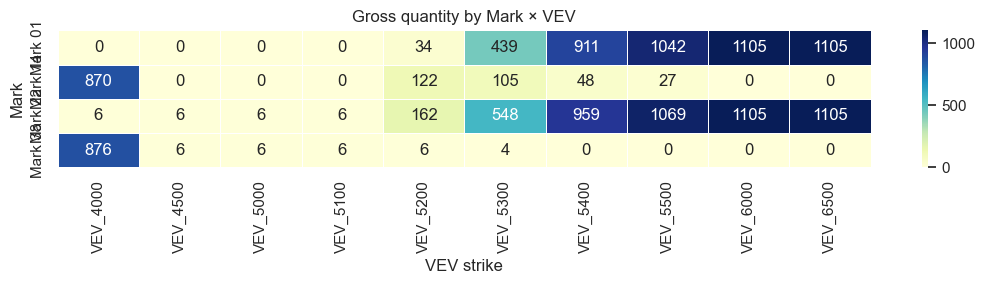

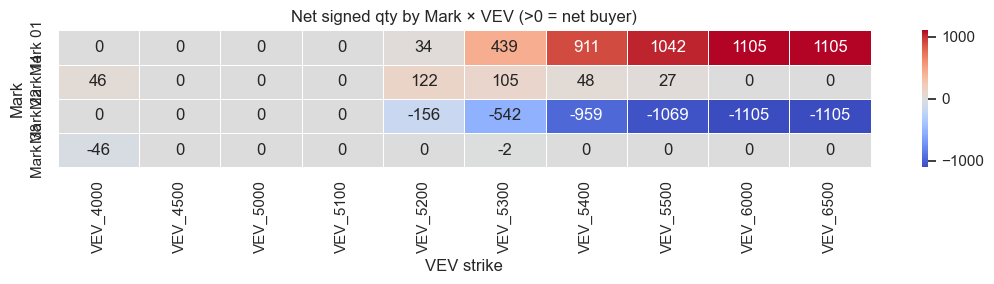

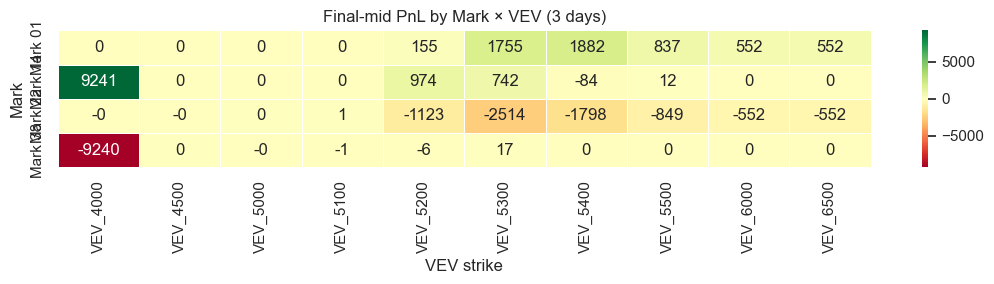

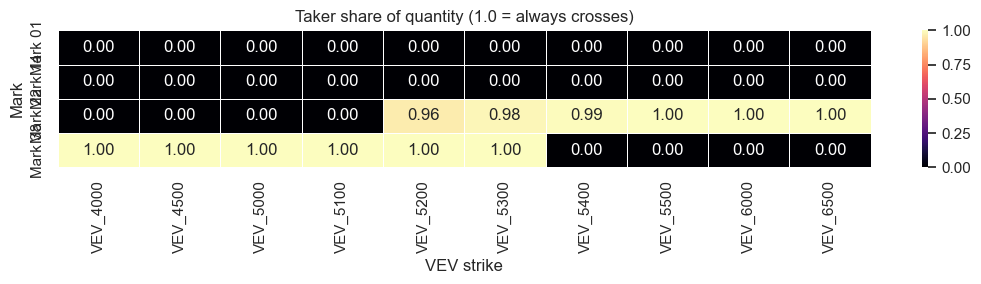

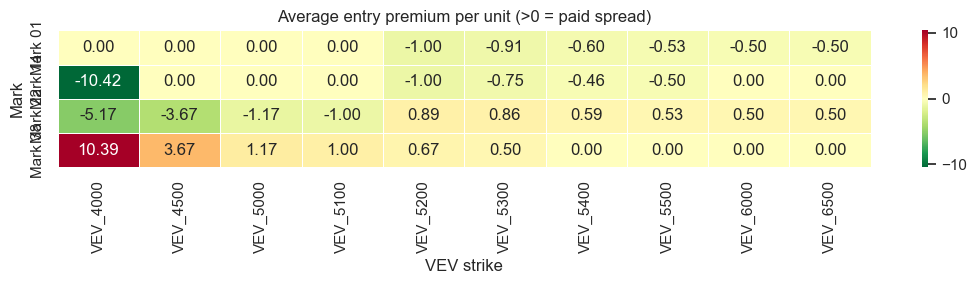

In [5]:
def heat(metric, title, fmt='.0f', cmap='RdYlGn'):
    pivot = summary.pivot(index='mark', columns='product', values=metric).reindex(columns=VEV_ORDER).fillna(0)
    plt.figure(figsize=(11, max(3, 0.5 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.4, linecolor='white')
    plt.title(title)
    plt.xlabel('VEV strike'); plt.ylabel('Mark')
    plt.tight_layout()
    plt.show()

heat('gross_qty', 'Gross quantity by Mark × VEV', '.0f', 'YlGnBu')
heat('net_qty',   'Net signed qty by Mark × VEV (>0 = net buyer)', '.0f', 'coolwarm')
heat('final_pnl', 'Final-mid PnL by Mark × VEV (3 days)',          '.0f', 'RdYlGn')
heat('taker_pct', 'Taker share of quantity (1.0 = always crosses)', '.2f', 'magma')
heat('avg_entry_premium', 'Average entry premium per unit (>0 = paid spread)', '.2f', 'RdYlGn_r')

**Read.**

- *Gross qty / net qty.* Volume concentrates on **VEV_4000** (Marks 14/38
  duel, 870–876 each), the **OTM strikes 5300–6500** (Marks 01/22 duel,
  symmetric ±1100), and trickle on the others. Net-qty signs are perfectly
  symmetric: every strike has one Mark long, one short, by the same amount.
- *PnL.* The colour map is again paired: green cell on Mark 14 → red on
  Mark 38 at VEV_4000 (≈ ±$9.2K). Green on Mark 01 → red on Mark 22 across
  the full OTM column. The transfer is structural, not opportunistic.
- *Taker share.* Mark 22 and Mark 38 are 1.00 across their book. Mark 01
  and Mark 14 are ~0.00. There is no role-switching by strike — these are
  *strategy roles*, not strike-specific positions.
- *Entry premium.* Same signature: 22 and 38 pay positive premium on every
  fill; 01 and 14 receive it. Magnitudes match the strike spread (~0.5 on
  the OTMs, ~10 on VEV_4000).

## 5 — Hold-edge: does the price keep moving against the taker?

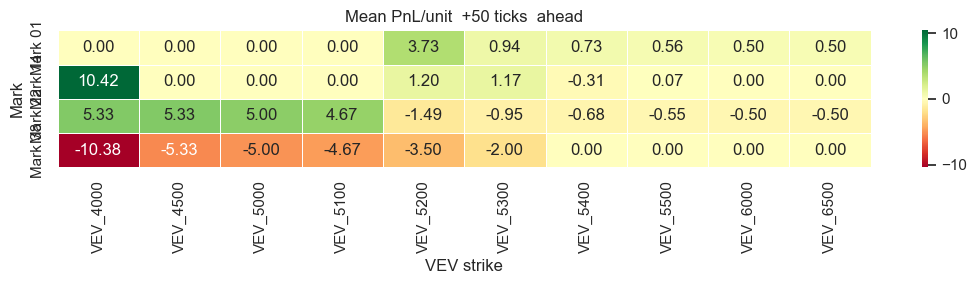

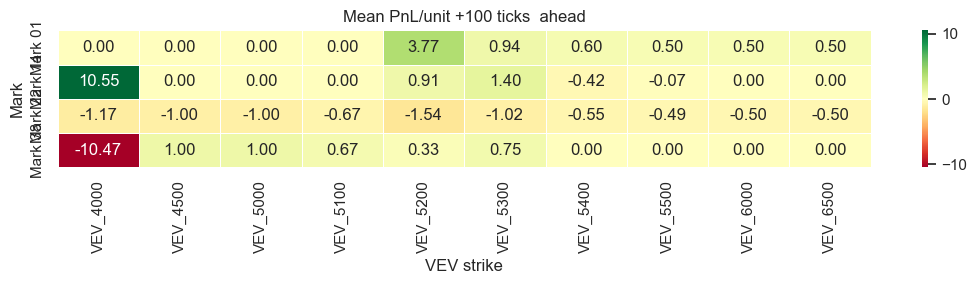

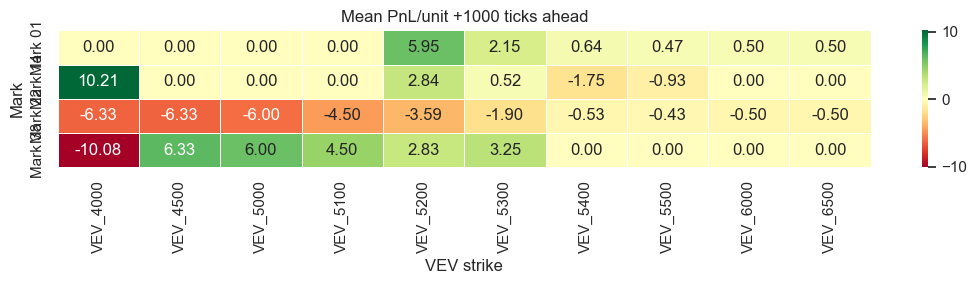

In [6]:
heat('hold_unit_mean_5000',   'Mean PnL/unit  +50 ticks  ahead', '.2f', 'RdYlGn')
heat('hold_unit_mean_10000',  'Mean PnL/unit +100 ticks  ahead', '.2f', 'RdYlGn')
heat('hold_unit_mean_100000', 'Mean PnL/unit +1000 ticks ahead', '.2f', 'RdYlGn')

**Read.** The forward-mid edge mirrors the entry-premium structure: passive
side keeps a positive edge over the taker for thousands of ticks. On
VEV_4000 the gap is **~+10 per unit forever** in Mark 14's favor — same as
the entry premium, meaning mid never reverts to where Mark 38 paid. On
OTM strikes the edge is small (~0.5) and decays slowly.

Implication: there is no mean reversion to fade. Mark 38's aggression on
VEV_4000 is *always* wrong — every print is at a price the mid does not
come back to. So the hold edge is mostly carry, not noise.

## 6 — Volume mix and trade timeline

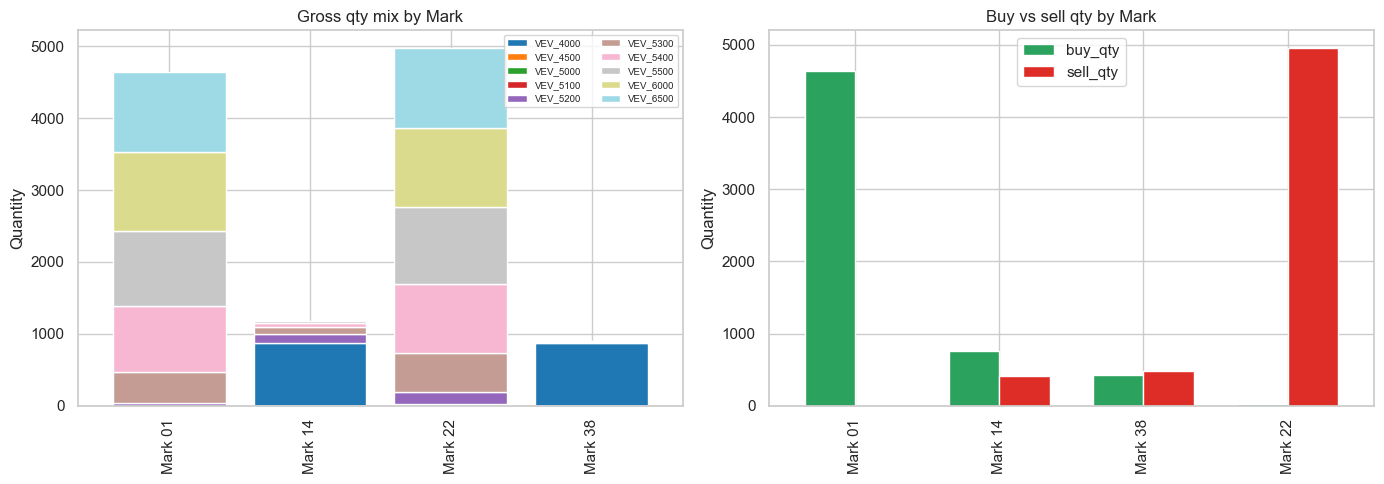

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

product_mix = summary.pivot(index='mark', columns='product', values='gross_qty').reindex(columns=VEV_ORDER).fillna(0)
product_mix.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20', width=0.8)
axes[0].set_title('Gross qty mix by Mark')
axes[0].set_ylabel('Quantity'); axes[0].set_xlabel('')
axes[0].legend(fontsize=7, ncol=2)

side_mix = summary.groupby('mark')[['buy_qty','sell_qty']].sum().sort_values('buy_qty', ascending=False)
side_mix.plot(kind='bar', ax=axes[1], color=['#2ca25f','#de2d26'], width=0.7)
axes[1].set_title('Buy vs sell qty by Mark')
axes[1].set_ylabel('Quantity'); axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

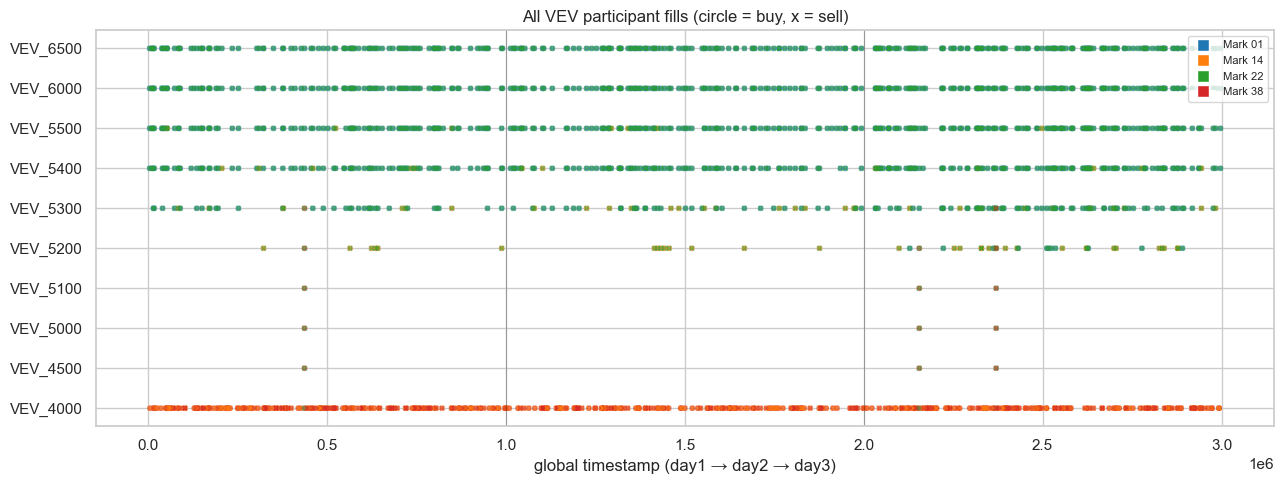

In [8]:
df = fills.copy()
df['product_idx'] = df['product'].map({p: i for i, p in enumerate(VEV_ORDER)})
marks_sorted = sorted(df.mark.unique())
mark_color = {m: plt.cm.tab10(i % 10) for i, m in enumerate(marks_sorted)}

fig, ax = plt.subplots(figsize=(13, 5))
for marker, sign in [('o', 1), ('x', -1)]:
    mask = df.side == sign
    ax.scatter(df.loc[mask, 'global_ts'], df.loc[mask, 'product_idx'],
               c=[mark_color[m] for m in df.loc[mask, 'mark']],
               s=10, marker=marker, alpha=0.55)
for b in [1_000_000, 2_000_000]:
    ax.axvline(b, color='black', lw=0.6, alpha=0.3)
handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=mark_color[m], markersize=8, label=m) for m in marks_sorted]
ax.legend(handles=handles, fontsize=8, loc='upper right')
ax.set_yticks(range(len(VEV_ORDER))); ax.set_yticklabels(VEV_ORDER)
ax.set_title('All VEV participant fills (circle = buy, x = sell)')
ax.set_xlabel('global timestamp (day1 → day2 → day3)')
plt.tight_layout(); plt.show()

**Read.** The timeline shows the duels playing out continuously across all
three days — no spikes, no quiet periods, no day-to-day regime change.
Mark 14/38 keep hammering VEV_4000; Mark 01/22 keep printing across the
whole OTM ladder. The roles are persistent.

## 7 — Counterparty pair table

In [9]:
pair_summary = (
    trades.groupby(['symbol','buyer','seller'], observed=True)
    .agg(trades=('quantity','size'),
         qty=('quantity','sum'),
         value=('price', lambda x: float((x * trades.loc[x.index,'quantity']).sum())))
    .reset_index().rename(columns={'symbol':'product'})
    .sort_values('qty', ascending=False)
)
print('Top 12 buyer↔seller pairs by quantity:')
print(pair_summary.head(12).to_string(index=False))

Top 12 buyer↔seller pairs by quantity:
 product   buyer  seller  trades  qty    value
VEV_6500 Mark 01 Mark 22     317 1105      0.0
VEV_6000 Mark 01 Mark 22     317 1105      0.0
VEV_5500 Mark 01 Mark 22     299 1042   4058.0
VEV_5400 Mark 01 Mark 22     263  911  10201.0
VEV_4000 Mark 14 Mark 38     232  458 567138.0
VEV_5300 Mark 01 Mark 22     132  439  15943.0
VEV_4000 Mark 38 Mark 14     207  412 517930.0
VEV_5200 Mark 14 Mark 22      33  122   9523.0
VEV_5300 Mark 14 Mark 22      30  105   4242.0
VEV_5400 Mark 14 Mark 22      13   48    668.0
VEV_5200 Mark 01 Mark 22      11   34   2225.0
VEV_5500 Mark 14 Mark 22       7   27    144.0


**Read.** Two pair clusters dominate:

1. **Mark 01 (buyer) ↔ Mark 22 (seller)** on every OTM strike from 5200 up
   to 6500 — 1100+ qty per strike, 5 strikes. Mark 01 always sits on the
   bid; Mark 22 always crosses to lift it.
2. **Mark 14 (buyer) ↔ Mark 38 (seller)** on VEV_4000 (and tiny VEV_4500)
   — 458 qty buying, 412 selling between them. Both sides print, but
   Mark 14 is always the passive side, Mark 38 always the taker.

Smaller pair: **Mark 14 ↔ Mark 22** on the in-between strikes (5200–5500),
suggesting Mark 14 occasionally extends his quote there. Magnitudes are
small.

## 8 — Deep dive: VEV_4000 (the big-ticket duel)

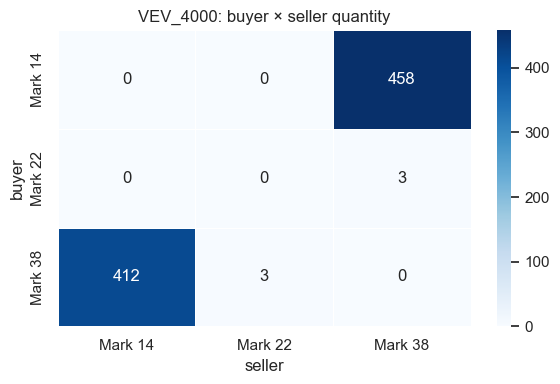

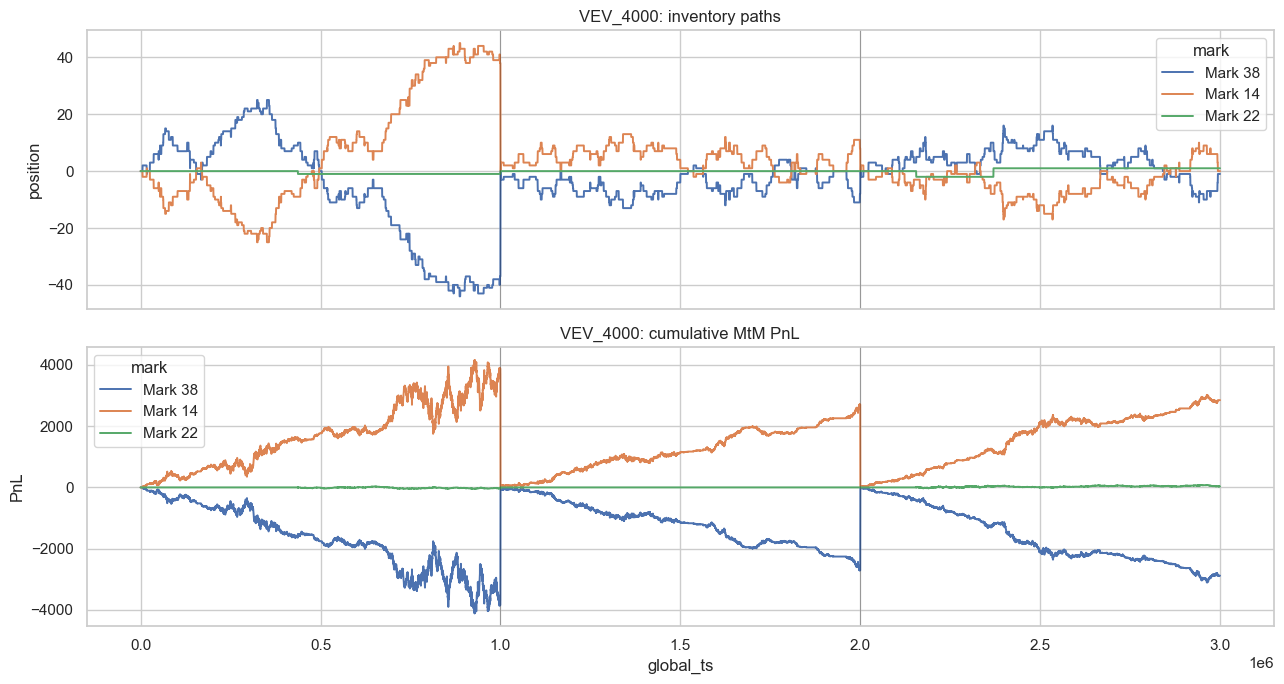

In [10]:
prod = 'VEV_4000'
sub = fills[fills['product'] == prod]
pp  = prices[prices['product'] == prod].copy()
pp['global_ts'] = (pp['day'] - 1) * 1_000_000 + pp['timestamp']

# Pair quantity heatmap
pair = pair_summary[pair_summary['product'] == prod]
pivot = pair.pivot(index='buyer', columns='seller', values='qty').fillna(0)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.4, ax=ax)
ax.set_title(f'{prod}: buyer × seller quantity')
plt.tight_layout(); plt.show()

# Inventory + cumulative MtM PnL paths
def running_paths(product, top_marks):
    p = prices[prices['product'] == product]
    rows = []
    for day, day_prices in p.groupby('day'):
        day_prices = day_prices.sort_values('timestamp')
        for mark in top_marks:
            ev = (
                fills[(fills['product']==product) & (fills.day==day) & (fills.mark==mark)]
                .groupby('timestamp', observed=True)
                .agg(signed_qty=('signed_qty','sum'), cash_change=('cash_change','sum'))
                .sort_index()
            )
            pos = 0.0; cash = 0.0; idx = 0
            ets = ev.index.to_numpy(); qtys = ev['signed_qty'].to_numpy(); cashes = ev['cash_change'].to_numpy()
            for pr in day_prices.itertuples(index=False):
                while idx < len(ets) and ets[idx] <= pr.timestamp:
                    pos += qtys[idx]; cash += cashes[idx]; idx += 1
                rows.append({'global_ts': (day - 1) * 1_000_000 + pr.timestamp,
                             'mark': mark, 'position': pos,
                             'pnl': cash + pos * pr.mid_price,
                             'mid_price': pr.mid_price})
    return pd.DataFrame(rows)

top_marks = (sub.groupby('mark')['quantity'].sum().sort_values(ascending=False).head(4).index.tolist())
rp = running_paths(prod, top_marks)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
sns.lineplot(data=rp, x='global_ts', y='position', hue='mark', ax=axes[0], lw=1.4)
axes[0].set_title(f'{prod}: inventory paths'); axes[0].set_ylabel('position')
sns.lineplot(data=rp, x='global_ts', y='pnl', hue='mark', ax=axes[1], lw=1.4)
axes[1].set_title(f'{prod}: cumulative MtM PnL'); axes[1].set_ylabel('PnL')
for ax in axes:
    for b in [1_000_000, 2_000_000]:
        ax.axvline(b, color='black', lw=0.6, alpha=0.3)
plt.tight_layout(); plt.show()

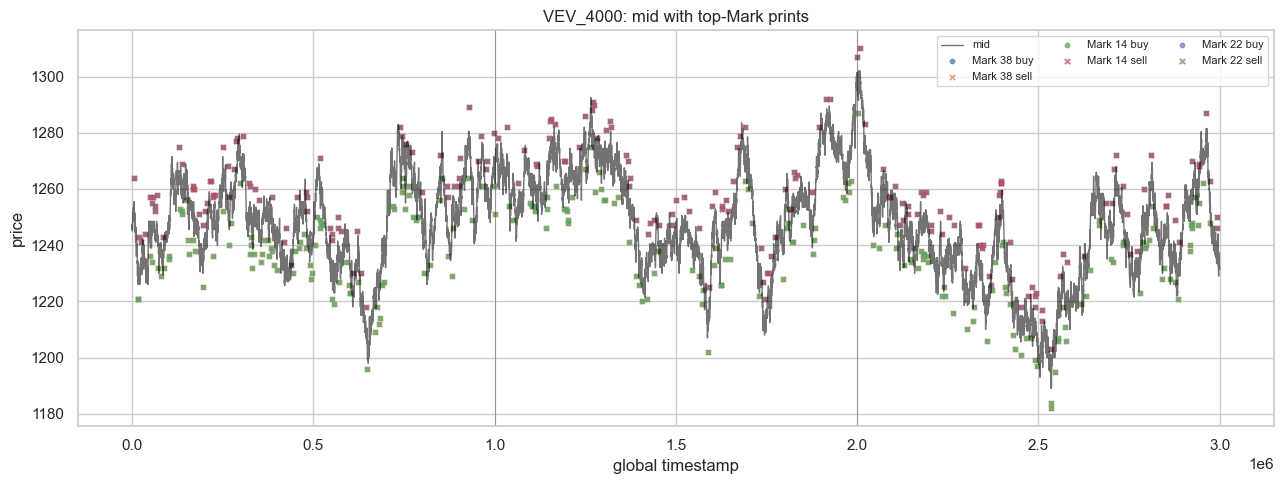

In [11]:
# Overlay the trades on top of the mid
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pp['global_ts'], pp['mid_price'], color='black', alpha=0.55, lw=1, label='mid')
for mark in top_marks:
    mt = sub[sub['mark'] == mark]
    if mt.empty: continue
    buys = mt[mt.side > 0]; sells = mt[mt.side < 0]
    ax.scatter(buys['global_ts'],  buys['price'],  s=10, alpha=0.7, label=f'{mark} buy')
    ax.scatter(sells['global_ts'], sells['price'], s=14, marker='x', alpha=0.7, label=f'{mark} sell')
for b in [1_000_000, 2_000_000]:
    ax.axvline(b, color='black', lw=0.6, alpha=0.3)
ax.set_title(f'{prod}: mid with top-Mark prints')
ax.set_xlabel('global timestamp'); ax.set_ylabel('price')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

**Read — VEV_4000.**

- Pair heatmap: Mark 38 → Mark 14 (232 qty) and Mark 14 → Mark 38 (207 qty),
  with tiny crumbs to Mark 22. Two-player game.
- Inventory paths: Mark 14 oscillates around 0 with a small net-long bias;
  Mark 38 mirrors. Neither is accumulating — they're round-tripping
  inventory at fixed premium. The MtM-PnL chart shows a steady straight
  line: Mark 14 climbs to ~$10K over 3 days, Mark 38 falls by the same.
- Scatter: every Mark 14 sell prints on the upper edge, every buy on the
  lower edge — he's quoting both sides at a fixed premium and Mark 38 is
  always the one crossing.

Translation: VEV_4000 is structurally a Mark 14 ↔ Mark 38 spread-capture
loop at a *huge* half-spread (~10), worth ~$3.5K/day. To replicate Mark
14's role we'd need to be the inside two-sided quote on VEV_4000 with the
same priority — which the venue's DEEP_ITM voucher market (intrinsic-only)
is exactly the setup for.

## 9 — Deep dive: OTM ladder (Mark 01 vs Mark 22)

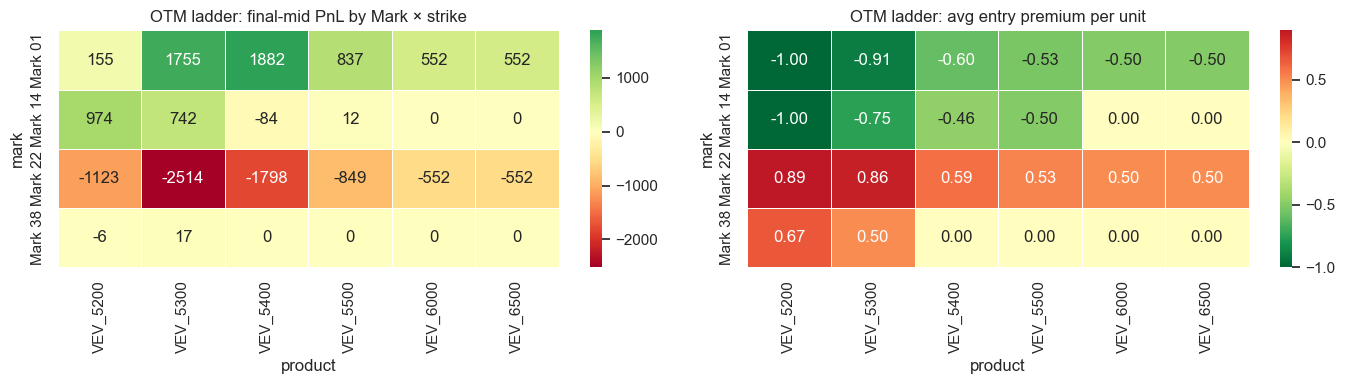

In [12]:
otm = ['VEV_5200','VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500']
sub = fills[fills['product'].isin(otm)]

# PnL contribution per (mark, strike)
pnl = sub.groupby(['mark','product'], observed=True)['final_pnl'].sum().unstack(fill_value=0)
pnl = pnl.reindex(columns=otm).reindex(['Mark 01','Mark 14','Mark 22','Mark 38'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pnl, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=axes[0], linewidths=0.4)
axes[0].set_title('OTM ladder: final-mid PnL by Mark × strike')

# Premium per unit
prem = sub.groupby(['mark','product'], observed=True)['entry_premium'].mean().unstack(fill_value=0)
prem = prem.reindex(columns=otm).reindex(['Mark 01','Mark 14','Mark 22','Mark 38'])
sns.heatmap(prem, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, ax=axes[1], linewidths=0.4)
axes[1].set_title('OTM ladder: avg entry premium per unit')
plt.tight_layout(); plt.show()

**Read — OTM ladder.** Across all six OTM strikes the pattern is identical:
Mark 01 collects ~0.5 per unit passively, Mark 22 pays it. Mark 14 chips
in on 5200–5400 (extending his quoting region toward ATM but not past
5500). Mark 38 only barely participates here. The PnL is small per strike
(≈ ±$1K each) but adds up across the chain.

Note: VEV_6000 and VEV_6500 print at *price 0* on every fill — those are
deep-OTM zero-bid strikes where the trade is essentially a free option for
Mark 01 (he gets long for free, mid stays at 0.5, no PnL transfer at
final mid because there's no convexity left). The premium-per-unit
heatmap shows ±0.5 — exactly half a tick.

## 10 — Per-Mark daily PnL by strike

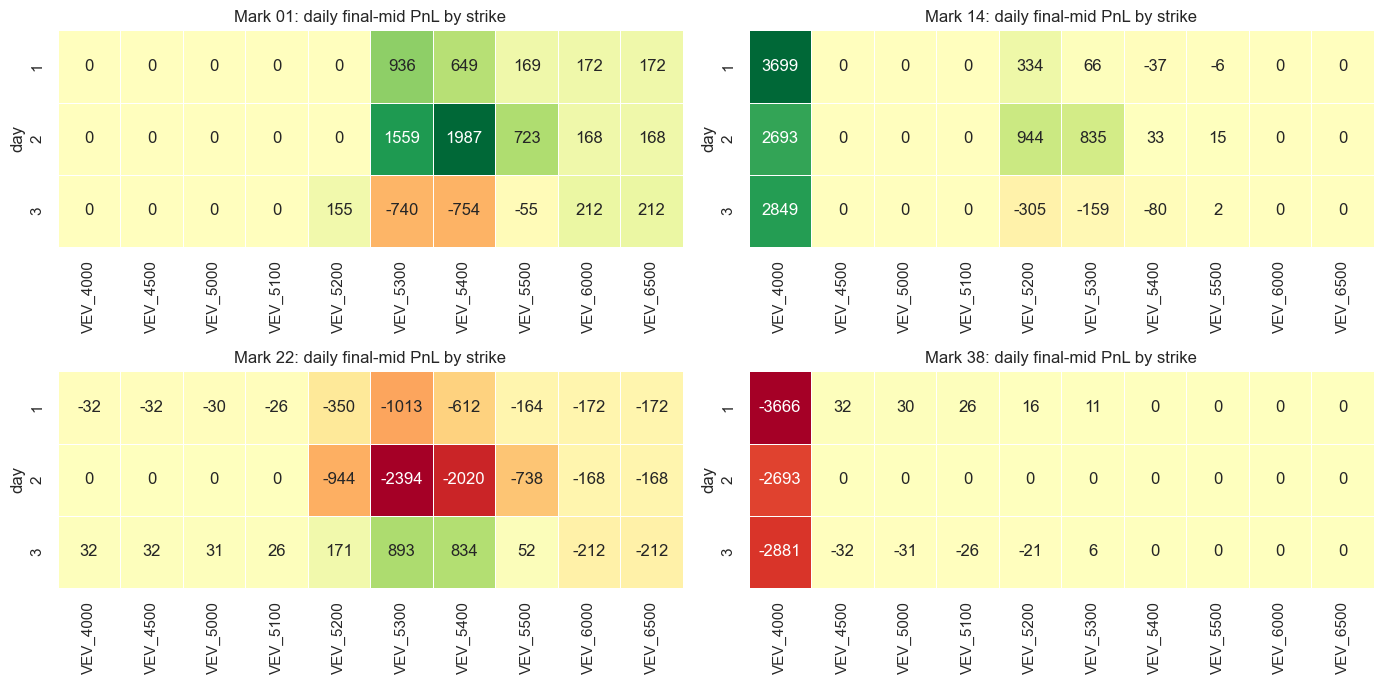

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, mark in zip(axes.flat, ['Mark 01','Mark 14','Mark 22','Mark 38']):
    daily = (
        fills[fills['mark'] == mark]
        .groupby(['day','product'], observed=True)['final_pnl'].sum()
        .unstack(fill_value=0).reindex(columns=VEV_ORDER).fillna(0)
    )
    sns.heatmap(daily, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.4, cbar=False)
    ax.set_title(f'{mark}: daily final-mid PnL by strike')
    ax.set_xlabel(''); ax.set_ylabel('day')
plt.tight_layout(); plt.show()

**Read.** PnL per Mark per strike is consistent day to day — no day where
the duel reverses. Mark 14 gains ~$3.6K/day on VEV_4000 every single day.
Mark 22 loses ~$0.5K–$1K/day across its OTM book. The flow is a
*structural primitive*, not a one-shot anomaly we can't count on.

## Bottom-line read

1. **Two structural duels.** Mark 01 ↔ Mark 22 on OTM (5200+); Mark 14 ↔
   Mark 38 on deep ITM (4000). In each pair one Mark is 100% passive
   quoter, the other 100% taker. Roles never flip.
2. **PnL transfer is huge on VEV_4000** (~$3.5K/day in Mark 14's favor)
   because Mark 38 crosses at ~10 ticks above the eventual mid. Smaller
   but persistent transfer on the OTM ladder (~$0.5/unit).
3. **No mean reversion to fade.** Forward-mid edges at +50 / +100 / +1000
   ticks all sustain the entry premium — this isn't noise that decays,
   it's a real spread that the takers consistently overpay.
4. **Strategy implications:**
   - Quoting passive on VEV_4000 (or any deep-ITM strike) at intrinsic ±
     small offset → high $/unit, low risk; we're stepping into Mark 14's
     role.
   - Quoting passive on the OTM ladder → small $/unit but volume (1100+
     per strike); profitable but needs many fills to add up.
   - Don't try to take from Mark 14 or Mark 01 — both round-trip near-flat
     and price every fill at adverse premium for the taker.
   - The day-to-day persistence means we can size into these positions
     without worrying about regime change inside the round.